# Detailed Error History Analysis for IaC Generation
This notebook analyzes the granular error history generated during iterative Infrastructure-as-Code (IaC) creation. 
The analysis draws from:
1. **Deployability-Centric IaC Generation**: Analyzing errors across the DevOps pipeline (Syntax Validation vs. Live Deployment) and iteration attempts.
2. **IaC Error Taxonomy**: Categorizing the underlying reasons for failure by examining specific error messages and problematic resources.

In [26]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import re
from collections import Counter

# Set plotting style
plt.style.use('seaborn-v0_8-whitegrid')
sns.set_context("notebook", font_scale=1.1)

# Load the granular error history dataset
# file_path = "./Result/error_tracking/openrouter/arcee-ai/trinity-large-preview:free_error_history.csv"
file_path = "./Result/error_tracking/openrouter/qwen/qwen3-235b-a22b-thinking-2507_error_history.csv"
df = pd.read_csv(file_path)

# Ensure timestamp is a datetime object for any potential time-series analysis
df['timestamp'] = pd.to_datetime(df['timestamp'])

# Display basic info
display(df.info())
display(df.head())

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1486 entries, 0 to 1485
Data columns (total 11 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   timestamp            1486 non-null   datetime64[ns]
 1   llm_type             1486 non-null   object        
 2   llm_model            1486 non-null   object        
 3   template_path        1486 non-null   object        
 4   row_number           1486 non-null   int64         
 5   iteration_number     1486 non-null   int64         
 6   error_stage          1486 non-null   object        
 7   stage_attempt_count  1486 non-null   int64         
 8   next_feedback_level  1486 non-null   object        
 9   error_message        1090 non-null   object        
 10  resource_name        1329 non-null   object        
dtypes: datetime64[ns](1), int64(3), object(7)
memory usage: 127.8+ KB


None

,timestamp,llm_type,llm_model,template_path,row_number,iteration_number,error_stage,stage_attempt_count,next_feedback_level,error_message,resource_name
0,2026-03-01 11:35:01,deepseek,openrouter/qwen/qwen3-235b-a22b-thinking-2507,llm_generated_data/template/iterative/deepseek/openrouter/qwen/qwen3-235b-a22b-thinking-2507/row_0_update_1_template_20260301_113314.yaml,0,1,syntax_validation,0,simple,{'Fn::Sub': '${AWS::StackName}-basic-queue'} is not of type 'string',QueueName
1,2026-03-01 11:40:23,deepseek,openrouter/qwen/qwen3-235b-a22b-thinking-2507,llm_generated_data/template/iterative/deepseek/openrouter/qwen/qwen3-235b-a22b-thinking-2507/row_3_update_1_template_20260301_113946.yaml,3,1,syntax_validation,0,simple,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from deletion,WebsiteBucket
2,2026-03-01 11:42:29,deepseek,openrouter/qwen/qwen3-235b-a22b-thinking-2507,llm_generated_data/template/iterative/deepseek/openrouter/qwen/qwen3-235b-a22b-thinking-2507/row_3_update_2_template_20260301_114023.yaml,3,2,syntax_validation,1,simple,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from deletion,WebsiteBucket
3,2026-03-01 11:44:05,deepseek,openrouter/qwen/qwen3-235b-a22b-thinking-2507,llm_generated_data/template/iterative/deepseek/openrouter/qwen/qwen3-235b-a22b-thinking-2507/row_3_update_3_template_20260301_114229.yaml,3,3,syntax_validation,2,moderate,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from deletion,WebsiteBucket
4,2026-03-01 11:44:05,deepseek,openrouter/qwen/qwen3-235b-a22b-thinking-2507,llm_generated_data/template/iterative/deepseek/openrouter/qwen/qwen3-235b-a22b-thinking-2507/row_3_update_3_template_20260301_114229.yaml,3,3,syntax_validation,2,moderate,A bucket with 'AccessControl' set should also have at least one 'OwnershipControl' configured,WebsiteBucket


## 1. Error Stage Distribution (DevOps Pipeline)
Following the "Deployability-Centric" methodology, we categorize where the LLM's generated code failed. 
Failures in early stages (like `syntax_validation`) suggest fundamental formatting or schema misunderstandings, whereas failures in `deployment` suggest valid code that violates cloud logic or permissions.

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_71832/2651403784.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=stage_counts.values, y=stage_counts.index, palette='viridis')


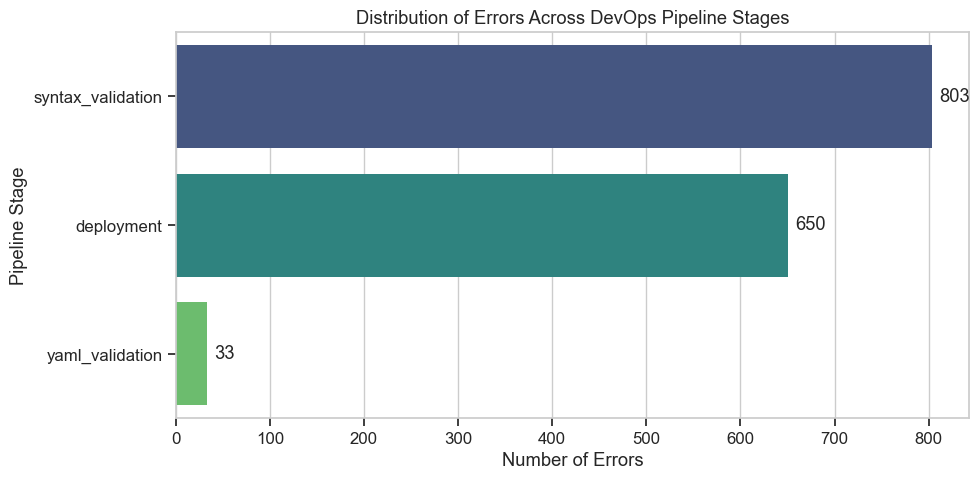

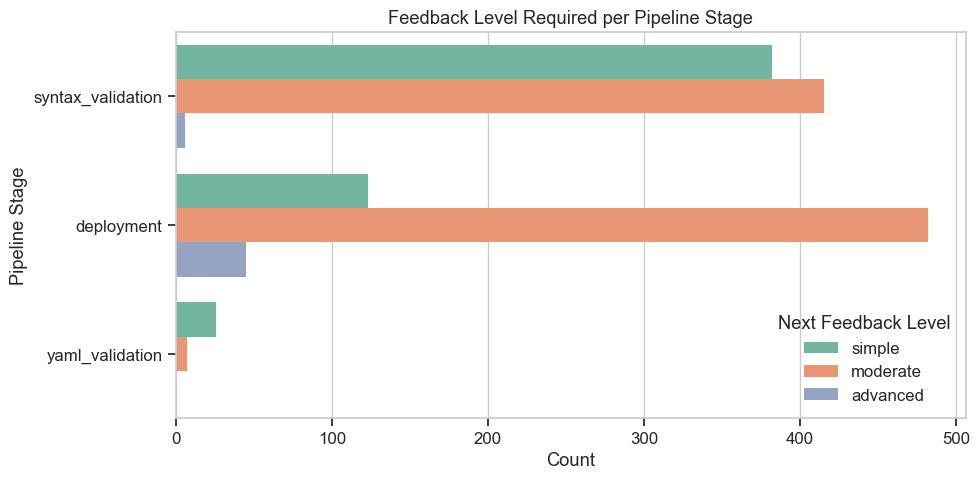

In [28]:
plt.figure(figsize=(10, 5))

# Count errors by stage
stage_counts = df['error_stage'].value_counts()

sns.barplot(x=stage_counts.values, y=stage_counts.index, palette='viridis')
plt.title('Distribution of Errors Across DevOps Pipeline Stages')
plt.xlabel('Number of Errors')
plt.ylabel('Pipeline Stage')

# Add exact counts to bars
for i, v in enumerate(stage_counts.values):
    plt.text(v + (max(stage_counts.values)*0.01), i, str(v), va='center')

plt.tight_layout()
plt.show()

# Breakdown of Feedback Levels given per stage
plt.figure(figsize=(10, 5))
sns.countplot(data=df, y='error_stage', hue='next_feedback_level', palette='Set2')
plt.title('Feedback Level Required per Pipeline Stage')
plt.xlabel('Count')
plt.ylabel('Pipeline Stage')
plt.legend(title='Next Feedback Level')
plt.tight_layout()
plt.show()

## 2. Iteration Analysis (Error Persistence)
This section tracks how many errors occur at each iteration step. A steep drop-off indicates the LLM successfully self-corrects based on feedback. A long tail suggests the LLM is getting stuck in feedback loops.

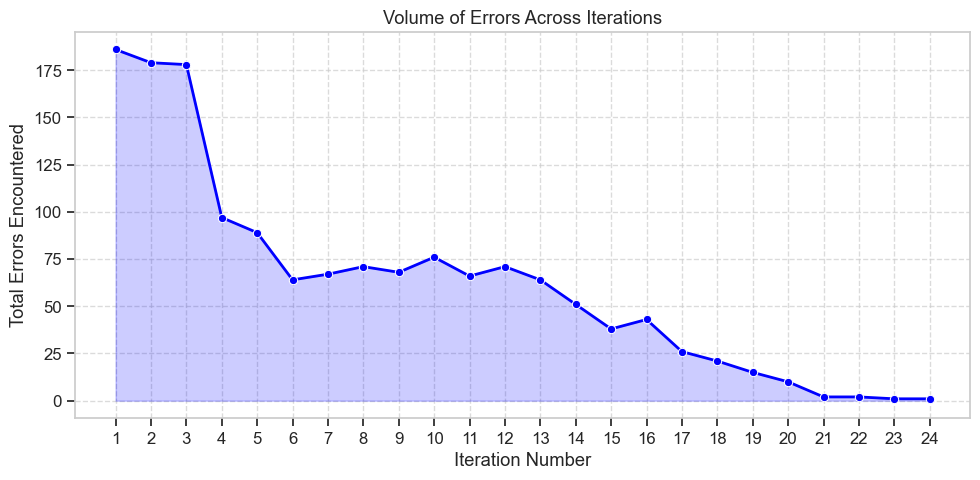

Average iterations required for problematic templates: 9.56
Max iterations hit by a single template: 24


In [30]:
plt.figure(figsize=(10, 5))

# Group by iteration number
iteration_counts = df.groupby('iteration_number').size()

sns.lineplot(x=iteration_counts.index, y=iteration_counts.values, marker='o', color='b', linewidth=2)
plt.title('Volume of Errors Across Iterations')
plt.xlabel('Iteration Number')
plt.ylabel('Total Errors Encountered')
plt.xticks(iteration_counts.index)
plt.grid(True, linestyle='--', alpha=0.7)

# Fill area under curve for visual effect
plt.fill_between(iteration_counts.index, iteration_counts.values, alpha=0.2, color='b')

plt.tight_layout()
plt.show()

# Let's look at average attempts per row (scenario)
errors_per_row = df.groupby('row_number')['iteration_number'].max()
print(f"Average iterations required for problematic templates: {errors_per_row.mean():.2f}")
print(f"Max iterations hit by a single template: {errors_per_row.max()}")

## 3. Most Problematic Cloud Resources
Which specific infrastructure components cause the most hallucinations or syntax errors? By analyzing the `resource_name` column, we can pinpoint whether the LLM struggles with Networking, IAM, Compute, or Storage.

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_71832/1158343557.py:8: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=top_resources.values, y=top_resources.index, palette='magma')


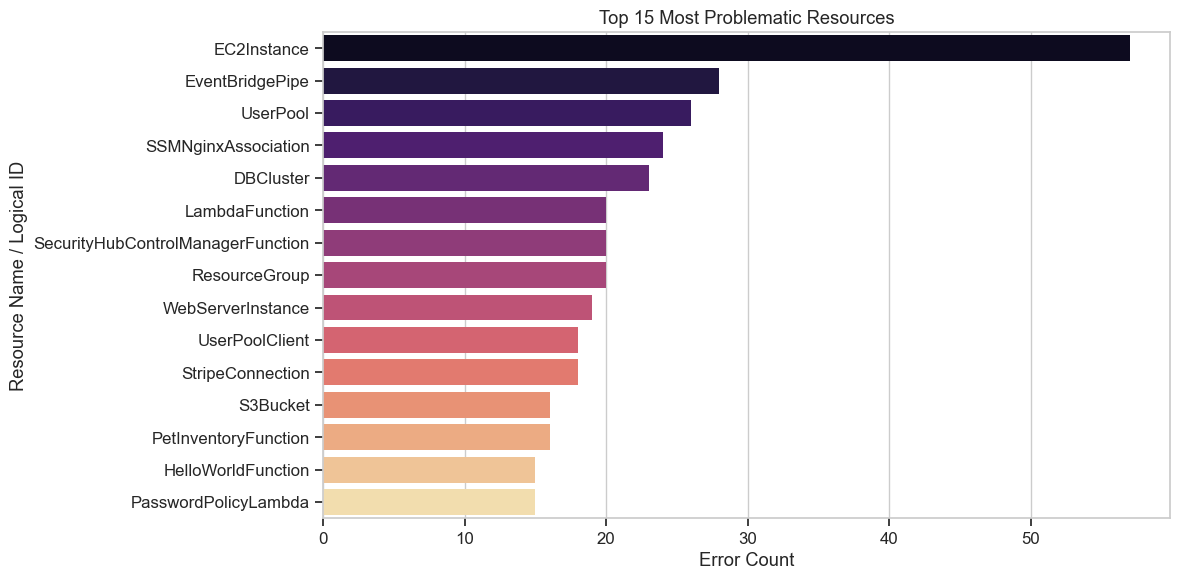

In [32]:
plt.figure(figsize=(12, 6))

# Filter out 'N/A' or completely missing resource names
valid_resources = df[df['resource_name'] != 'N/A']['resource_name'].dropna()

top_resources = valid_resources.value_counts().head(15)

sns.barplot(x=top_resources.values, y=top_resources.index, palette='magma')
plt.title('Top 15 Most Problematic Resources')
plt.xlabel('Error Count')
plt.ylabel('Resource Name / Logical ID')
plt.tight_layout()
plt.show()

## 4. Error Message Taxonomy & Keyword Extraction
To map these failures to the "Error Taxonomy" paper (e.g., Dependency Errors, Property Errors), we parse the `error_message` column. This NLP extraction helps identify the root causes (e.g., missing properties, invalid types, docker dependencies).

/var/folders/mr/k47n2bks0fs1y0cmq922vqbh0000gn/T/ipykernel_71832/283759116.py:29: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=list(counts), y=list(keywords), palette='crest')


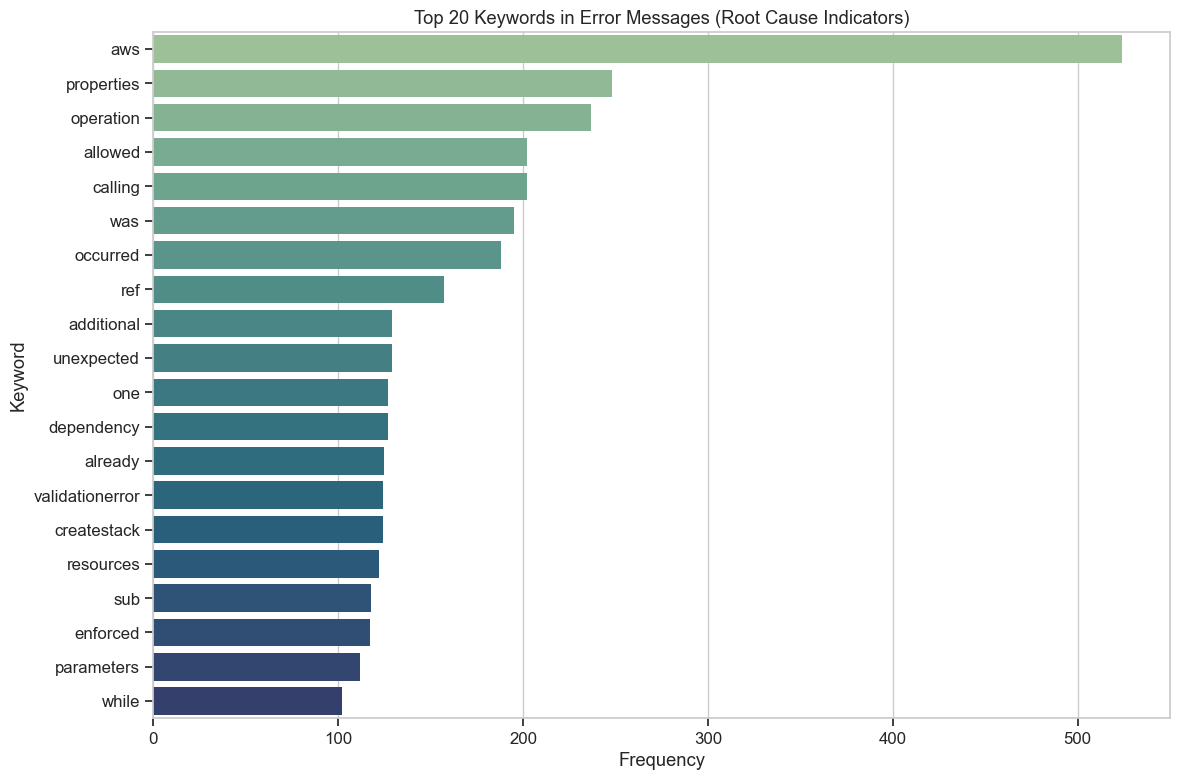


--- Sample of Raw Error Messages for Context ---


,error_stage,error_message
0,syntax_validation,{'Fn::Sub': '${AWS::StackName}-basic-queue'} is not of type 'string'
1,syntax_validation,Both 'UpdateReplacePolicy' and 'DeletionPolicy' are needed to protect resource from deletion
4,syntax_validation,A bucket with 'AccessControl' set should also have at least one 'OwnershipControl' configured
5,syntax_validation,'AccessControl' is a legacy property. Consider using 'AWS::S3::BucketPolicy' instead
6,deployment,"Resource handler returned message: ""User: arn:aws:iam::649872913223:root is not authorized to perform: s3:PutBucketPolicy on resource: ""arn:aws:s3:::validation-stack-d921aa00-websitebucket-7tlkceavntla"" because public policies are prevented by the BlockPublicPolicy setting in S3 Block Public Access. (Service: S3, Status Code: 403, Request ID: 5XZEG9T92Q91GPPG, Extended Request ID: MpoQYB6VMGCV6MFXBhPtrLKN7ktA5IGOcQNGcIcOW6fxb2yfArhtdsnhWwJcWBm+Dex44DHh20rIyJlDrplNaE/B4zGqmVRv) (SDK Attempt Count: 1)"" (RequestToken: 0331fcf9-9be7-64b4-1035-19657ee9906a, HandlerErrorCode: AccessDenied)"
7,syntax_validation,'Fn::Sub' isn't needed because there are no variables
8,syntax_validation,Default should be allowed by AllowedPattern
10,syntax_validation,Use dynamic references over parameters for secrets
11,syntax_validation,'DBSubnetGroup' dependency already enforced by a 'Ref' at 'Resources/DBCluster/Properties/DBSubnetGroupName'
12,syntax_validation,'DBSecurityGroup' dependency already enforced by a 'GetAtt' at 'Resources/DBCluster/Properties/VpcSecurityGroupIds/0'


In [34]:
# Extract and clean error messages
error_texts = df['error_message'].dropna().astype(str)

# Filter out N/A rows
error_texts = error_texts[error_texts != 'N/A']

# Tokenize words (keeping only alphabetical strings)
combined_text = " ".join(error_texts).lower()
words = re.findall(r'[a-z]+', combined_text)

# Define a custom list of stop words to filter out structural noise
stop_words = set([
    'the', 'is', 'in', 'to', 'for', 'of', 'and', 'with', 'on', 'not', 'be', 'an', 'as', 
    'at', 'it', 'this', 'that', 'from', 'by', 'are', 'or', 'which', 'error', 'failed',
    'resource', 'reason', 'must', 'have', 'when', 'a', 'an', 'can', 'only', 'value', 'values'
])

# Filter words
meaningful_words = [w for w in words if w not in stop_words and len(w) > 2]

# Get top keywords
word_counts = Counter(meaningful_words)
top_keywords = word_counts.most_common(20)

if top_keywords:
    keywords, counts = zip(*top_keywords)
    
    plt.figure(figsize=(12, 8))
    sns.barplot(x=list(counts), y=list(keywords), palette='crest')
    plt.title('Top 20 Keywords in Error Messages (Root Cause Indicators)')
    plt.xlabel('Frequency')
    plt.ylabel('Keyword')
    plt.tight_layout()
    plt.show()

print("\n--- Sample of Raw Error Messages for Context ---")
pd.set_option('display.max_colwidth', None)
display(df[['error_stage', 'error_message']].drop_duplicates().head(10))

## 5. Learning vs. Repeating Errors (Feedback Loop Analysis)
In a true "Deployability-Centric" simulation, an LLM should learn from the compiler/deployment feedback and resolve the error in the next iteration. 
If the exact same error message appears across consecutive iterations for the same scenario, it indicates a **Reasoning Failure** or **Context Ignored** behavior, where the LLM is stuck in a loop and failing to incorporate the feedback.

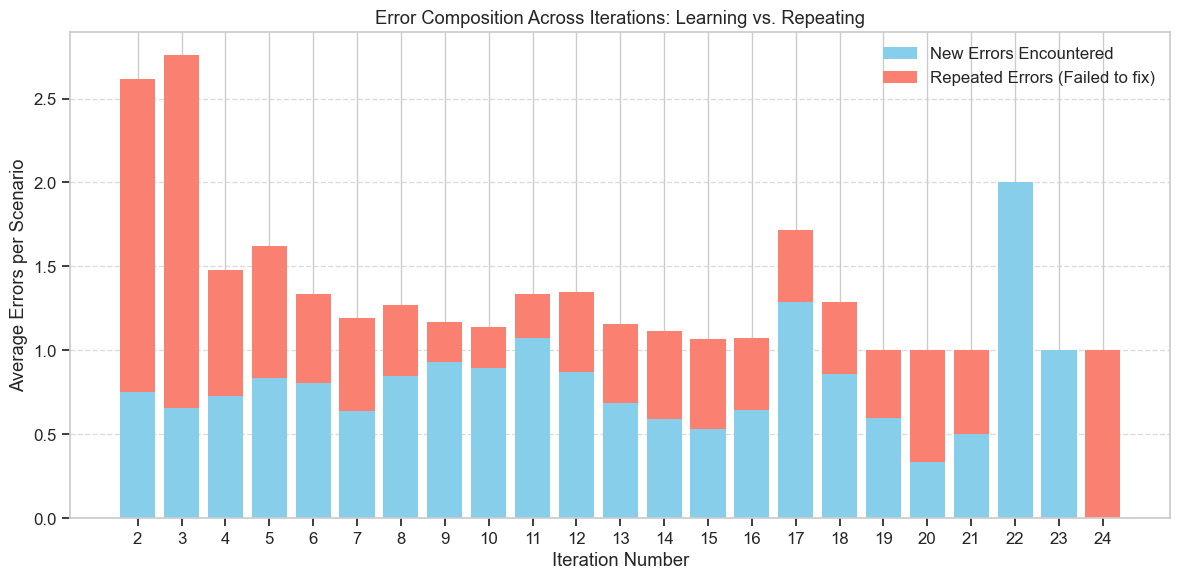

Overall Error Repetition Rate: 51.82%
*(This is the percentage of errors that the LLM failed to resolve from the immediate previous iteration)*


In [36]:
# Create a clean dataframe of just the errors per scenario and iteration
# We drop N/A errors and deduplicate in case the same error is logged twice in one iteration
clean_errors = df.dropna(subset=['error_message']).copy()
clean_errors = clean_errors[clean_errors['error_message'] != 'N/A']
unique_iter_errors = clean_errors[['row_number', 'iteration_number', 'error_message']].drop_duplicates()

# Group errors into sets for each iteration step
error_sets = unique_iter_errors.groupby(['row_number', 'iteration_number'])['error_message'].apply(set).reset_index()

# Shift the errors within each scenario (row_number) to compare with the previous iteration
error_sets['prev_iteration_errors'] = error_sets.groupby('row_number')['error_message'].shift(1)

# Function to calculate how many errors carried over from the exact previous step
def calc_repeated(row):
    if pd.isna(row['prev_iteration_errors']) or not isinstance(row['prev_iteration_errors'], set):
        return 0
    return len(row['error_message'].intersection(row['prev_iteration_errors']))

# Function to calculate how many errors are completely new in this iteration
def calc_new(row):
    if pd.isna(row['prev_iteration_errors']) or not isinstance(row['prev_iteration_errors'], set):
        return len(row['error_message'])
    return len(row['error_message'] - row['prev_iteration_errors'])

error_sets['repeated_errors'] = error_sets.apply(calc_repeated, axis=1)
error_sets['new_errors'] = error_sets.apply(calc_new, axis=1)

# Aggregate the average repeated vs new errors by iteration number
iteration_trends = error_sets.groupby('iteration_number')[['repeated_errors', 'new_errors']].mean().reset_index()

# We start plotting from Iteration 2 (since Iteration 1 cannot have "repeated" errors from a previous step)
iteration_trends_plot = iteration_trends[iteration_trends['iteration_number'] > 1]

plt.figure(figsize=(12, 6))

# Create a stacked bar chart
plt.bar(iteration_trends_plot['iteration_number'], iteration_trends_plot['new_errors'], 
        label='New Errors Encountered', color='skyblue')
plt.bar(iteration_trends_plot['iteration_number'], iteration_trends_plot['repeated_errors'], 
        bottom=iteration_trends_plot['new_errors'], label='Repeated Errors (Failed to fix)', color='salmon')

plt.title('Error Composition Across Iterations: Learning vs. Repeating')
plt.xlabel('Iteration Number')
plt.ylabel('Average Errors per Scenario')
plt.xticks(iteration_trends_plot['iteration_number'])
plt.legend()
plt.grid(axis='y', linestyle='--', alpha=0.7)
plt.tight_layout()
plt.show()

# Calculate overall stubbornness (percentage of all errors after iter 1 that were repeats)
total_subsequent_errors = error_sets[error_sets['iteration_number'] > 1]['error_message'].apply(len).sum()
total_repeated = error_sets['repeated_errors'].sum()

if total_subsequent_errors > 0:
    stubborn_rate = (total_repeated / total_subsequent_errors) * 100
    print(f"Overall Error Repetition Rate: {stubborn_rate:.2f}%")
    print("*(This is the percentage of errors that the LLM failed to resolve from the immediate previous iteration)*")